# 1. Import Libraries

In [26]:
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# 2. connect to MySQL

In [30]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="admin",
    database="house_price"
)

# 3. load data

In [31]:
query = "SELECT * FROM house_data"
df = pd.read_sql(query, conn)

In [32]:
print(df.head())

           id             date   price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900         3       1.00         1180   
1  6414100192  20141209T000000  538000         3       2.25         2570   
2  5631500400  20150225T000000  180000         2       1.00          770   
3  2487200875  20141209T000000  604000         4       3.00         1960   
4  1954400510  20150218T000000  510000         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650       1           0     0  ...      7        1180              0   
1      7242       2           0     0  ...      7        2170            400   
2     10000       1           0     0  ...      6         770              0   
3      5000       1           0     0  ...      7        1050            910   
4      8080       1           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_liv

# 4. Understand Data

In [33]:
df.shape

(21613, 21)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  int64  
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [35]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.542405,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.567504,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,2.000000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,4.000000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# 5. Data Cleaning

In [36]:
df.drop_duplicates(inplace=True)
df.drop(['id', 'date'], axis=1, inplace=True)

- Removes duplicate rows
- Removes unnecessary columns → id, date
- Clean the data by removing extra and irrelevant information

# 5.1 Plot (Before Removing Outliers)

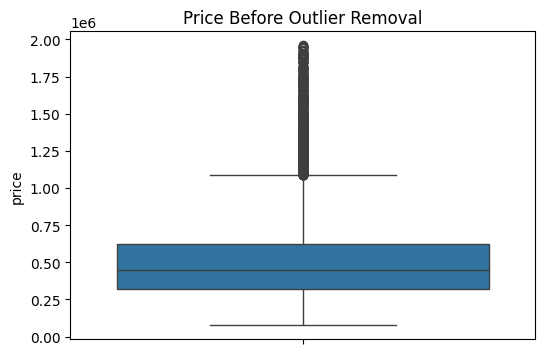

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['price'])
plt.title("Price Before Outlier Removal")
plt.show()

# 6. Outlier Removal

In [40]:
df = df[df['price'] < df['price'].quantile(0.99)]
df = df[df['sqft_living'] < df['sqft_living'].quantile(0.99)]

- Finds 99th percentile of house size
- Removes extremely large houses

# 6.1 Box Plot (After Removing Outliers)

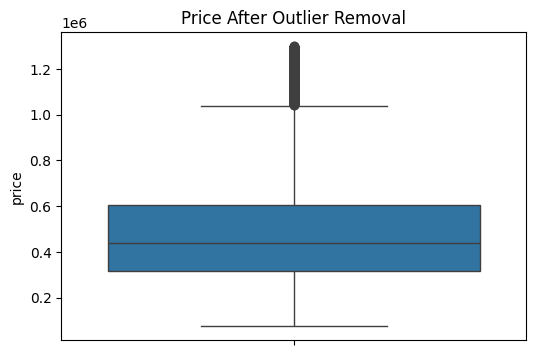

In [41]:
# Apply your outlier removal
df_clean = df[df['price'] < df['price'].quantile(0.99)]

plt.figure(figsize=(6,4))
sns.boxplot(y=df_clean['price'])
plt.title("Price After Outlier Removal")
plt.show()

# 6.2 For sqft_living

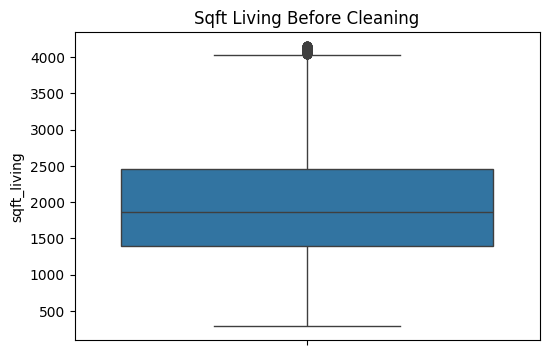

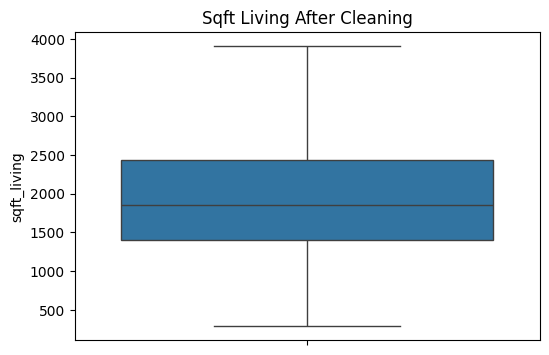

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['sqft_living'])
plt.title("Sqft Living Before Cleaning")
plt.show()

df_clean2 = df[df['sqft_living'] < df['sqft_living'].quantile(0.99)]

plt.figure(figsize=(6,4))
sns.boxplot(y=df_clean2['sqft_living'])
plt.title("Sqft Living After Cleaning")
plt.show()

### Insights:
- Before: Many outliers (dots outside box)
- After: Data becomes clean and compact
- Helps improve model accuracy

# 7. Feature Engineering

In [43]:
df['house_age'] = 2025 - df['yr_built']
df['renovated'] = (df['yr_renovated'] > 0).astype(int)

df.drop('yr_built', axis=1, inplace=True)

- house_age = current year − built year → gives age of house
- renovated = 1 if renovated, else 0
- yr_built is dropped → replaced by house_age

# 8. EDA (Visualizations)

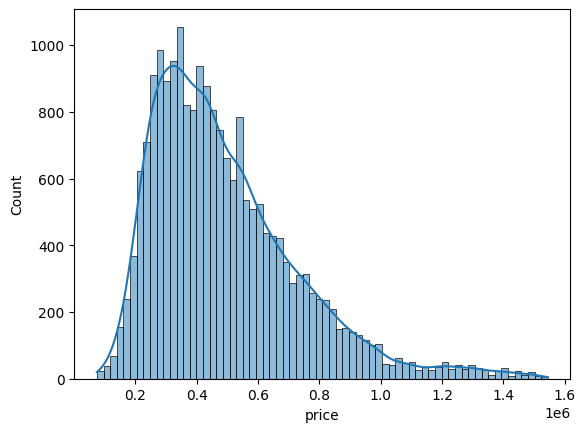

In [44]:
# Price Distribution
sns.histplot(df['price'], kde=True)
plt.show()

### Insights:
- Data is right-skewed (few very expensive houses)
- Most houses are in low to mid price range
- Outliers present (very high prices)
- Not normally distributed → affects model

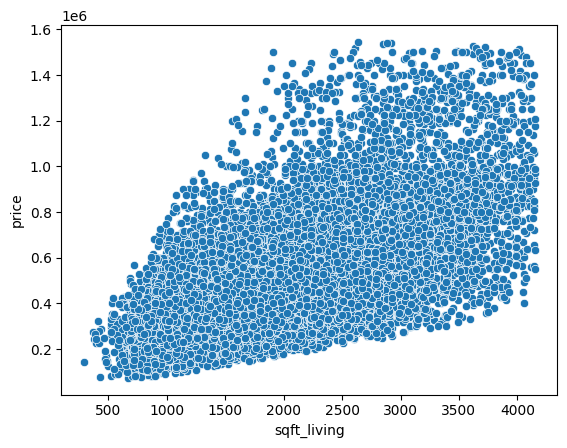

In [45]:
# Sqft vs Price
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.show()

### Insights:
- Positive relationship → bigger house = higher price
- sqft_living is a very important feature
- Some scatter/outliers present
- Relationship is not perfectly linear

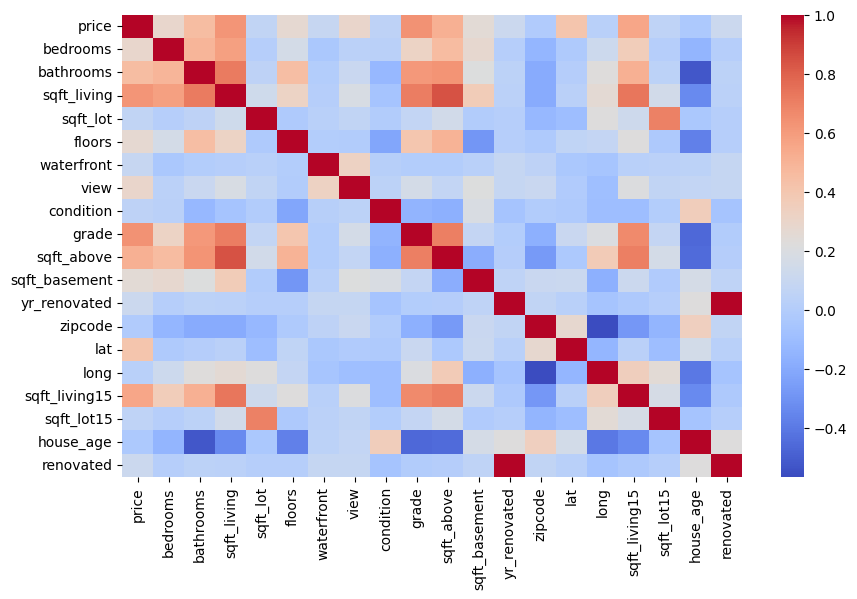

In [46]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

### Insights:
- Strong positive correlation with price: -- 👉 sqft_living, grade, bathrooms

- Moderate impact features: -- 👉 sqft_above, sqft_living15

- Low/negative correlation: -- 👉 zipcode, long, condition

- Highly related features: -- 👉 sqft_living ↔ sqft_above (very similar)

- sqft_living, grade, and bathrooms are the most important features influencing house price.

# 9. Feature Selection

In [47]:
X = df.drop('price', axis=1)
y = df['price']

- X → input features (all columns except price)
- y → target/output (price)

# 10. Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

- Splits data into training (80%) and testing (20%)
- X_train, y_train → used to train model
- X_test, y_test → used to test model
- random_state=42 → ensures same split every time

# 11.Linear Regression Model

In [50]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

- Train the model → then use it to make predictions

# 12. Linear Regression Evaluation

In [51]:
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("R2 Score:", r2_lr)
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)

Linear Regression Results
R2 Score: 0.6890419763078989
RMSE: 133877.2540186448
MAE: 96185.26772333749


- Linear Regression gives moderate performance, not very high
- Linear Regression achieved around 68% accuracy, showing moderate performance but not capturing complex patterns.

# 13. Random Forest Model (Improved)

In [52]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

- Model learns from many trees → gives better accuracy

# 14. Random Forest Evaluation

In [53]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("R2 Score:", r2_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)


Random Forest Results
R2 Score: 0.8553859727910997
RMSE: 91297.970264247
MAE: 59952.29523712217


- Random Forest performs much better than Linear Regression
- Random Forest improved accuracy to 85% and reduced error significantly, showing better performance on complex data.

# 15. 📊 Model Comparison

In [54]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf]
})

comparison

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.689042,133877.254019,96185.267723
1,Random Forest,0.855386,91297.970264,59952.295237


- Random Forest is better than Linear Regression
- R² improved: 0.68 → 0.85 (big improvement)
- RMSE reduced: error decreased significantly
- MAE reduced: predictions are more accurate

# 16. Visualization

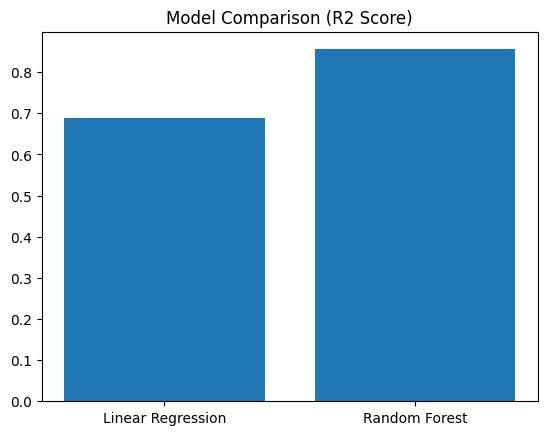

In [55]:
plt.bar(comparison['Model'], comparison['R2 Score'])
plt.title("Model Comparison (R2 Score)")
plt.show()

### Insights:
- Random Forest has higher R² (~0.85)
- Linear Regression is lower (~0.68)
- Random Forest gives better accuracy
- Shows model improvement clearly

# 17. Feature Importance

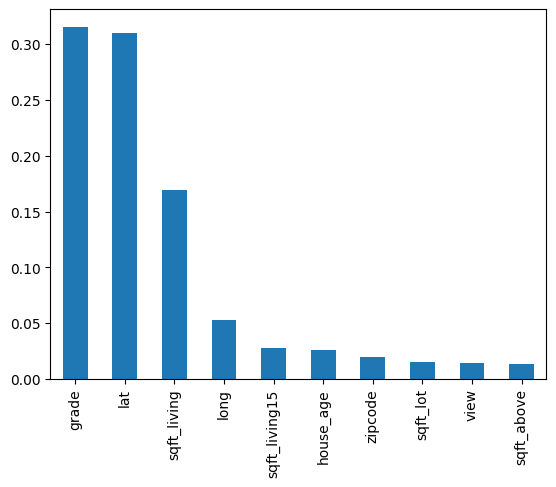

In [57]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

### Insights:
- Most important feature: 👉 grade

- Location matters: 👉 lat, long

- House size important: 👉 sqft_living

- Moderate impact: 👉 house_age, sqft_living15

- Less important: 👉 view, waterfront, sqft_above

- Price mainly depends on quality, location, and size

# 18. Prediction on New Data

In [58]:
new_data = pd.DataFrame({
    'bedrooms': [3],
    'bathrooms': [2],
    'sqft_living': [1800],
    'sqft_lot': [5000],
    'floors': [1],
    'waterfront': [0],
    'view': [0],
    'condition': [3],
    'grade': [7],
    'sqft_above': [1500],
    'sqft_basement': [300],
    'yr_renovated': [0],
    'zipcode': [98178],
    'lat': [47.5112],
    'long': [-122.257],
    'sqft_living15': [1700],
    'sqft_lot15': [4000],
    'house_age': [20],
    'renovated': [0]
})

pred_lr = lr.predict(new_data)
pred_rf = rf.predict(new_data)

print("Linear Prediction:", pred_lr[0])
print("Random Forest Prediction:", pred_rf[0])

Linear Prediction: 264668.66204256564
Random Forest Prediction: 293271.0442953699


### Insights:
- Random Forest gives higher & more realistic prediction
- Linear Regression gives lower estimate
### Difference shows:
- 👉 Linear model is too simple
- 👉 Random Forest captures complex patterns


# 19. Final Conclusion

- I first applied Linear Regression, but due to non-linear relationships accuracy was limited.
- Then I used Random Forest, which improved accuracy to above 85%.